In [1]:
from pathlib import Path
import pandas as pd
import sys

# Check that we run on the right .venv
print(sys.path)
ROOT_FOLDER = Path("").absolute()
DATA_FOLDER = ROOT_FOLDER / "data"
DATA_FOLDER

['C:\\Python313\\python313.zip', 'C:\\Python313\\DLLs', 'C:\\Python313\\Lib', 'C:\\Python313', 'C:\\_dev\\python_ws\\18_alarm_building\\bms-alarm-timeseries-periodic\\.venv', '', 'C:\\_dev\\python_ws\\18_alarm_building\\bms-alarm-timeseries-periodic\\.venv\\Lib\\site-packages']


WindowsPath('C:/_dev/python_ws/18_alarm_building/bms-alarm-timeseries-periodic/data')

# 1. Reading the data

In [2]:
train_series = DATA_FOLDER / "DSPub237.parquet"
train_series = pd.read_parquet(train_series)
train_series

,Timestamp,AlarmActivity,AlarmId
0,2024-05-01 10:31:32.983200+00:00,True,A0
1,2024-05-01 11:13:48.977200+00:00,False,A0
2,2024-05-02 10:15:04.982900+00:00,True,A0
3,2024-05-02 11:18:54.977900+00:00,False,A0
4,2024-05-03 10:15:03.935200+00:00,True,A0
...,...,...,...
73374,2024-05-28 06:19:27.049800+00:00,False,A236
73375,2024-05-29 22:10:43.064000+00:00,True,A236
73376,2024-05-30 07:30:24.072500+00:00,False,A236
73377,2024-05-30 21:55:47.073000+00:00,True,A236


In [3]:
train_meta = DATA_FOLDER / "DSPub237Metadata.parquet"
train_meta = pd.read_parquet(train_meta)
train_meta

,IsDailyPeriodic,IsRepeatPeriodic
AlarmId,,
A0,True,True
A1,False,False
A2,False,False
A3,True,False
A4,True,False
...,...,...
A232,True,False
A233,True,False
A234,True,True


In [4]:
test_series = DATA_FOLDER / "DSPub237_test.parquet"
test_series = pd.read_parquet(test_series)
test_series

,Timestamp,AlarmId,AlarmActivity
0,2026-01-19 13:27:15.053500+00:00,A1000,True
1,2026-01-19 13:30:31.053100+00:00,A1000,False
2,2026-01-19 13:46:09.081200+00:00,A1000,True
3,2026-01-19 13:46:29.073500+00:00,A1000,False
4,2026-01-19 14:02:15.063600+00:00,A1000,True
...,...,...,...
37073,2026-01-31 11:30:48.073000+00:00,A1083,False
37074,2026-02-01 05:28:57.982700+00:00,A1083,True
37075,2026-02-01 10:45:45.050600+00:00,A1083,False
37076,2026-02-02 08:46:21.950100+00:00,A1083,True


In [ ]:
test_meta = DATA_FOLDER / "DSPub237Metadata_test.parquet"
test_meta = pd.read_parquet(test_meta)
test_meta

# 2. Overall statistics

## 2.1 Periodicity labels (metadata)

In [6]:
train_meta["IsPeriodic"] = train_meta["IsRepeatPeriodic"] | train_meta["IsDailyPeriodic"]
train_meta.sum()

IsDailyPeriodic     137
IsRepeatPeriodic     64
IsPeriodic          143
dtype: int64

In [7]:
test_meta["IsPeriodic"] = test_meta["IsRepeatPeriodic"] | test_meta["IsDailyPeriodic"]
test_meta.sum()

IsRepeatPeriodic    36
IsDailyPeriodic     52
IsPeriodic          57
dtype: int64

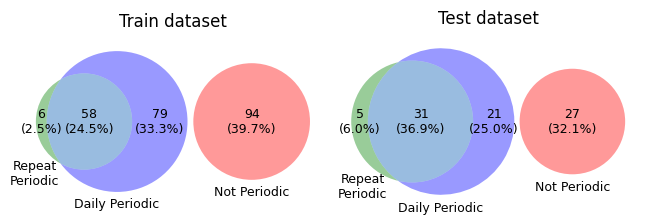

In [8]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# List of alarmIds of each kind
def extract_periodicity_sets(meta_df):
    np_alarm_ids = meta_df.loc[~meta_df["IsPeriodic"]].index.tolist()
    rp_alarm_ids = meta_df.loc[meta_df["IsRepeatPeriodic"]].index.tolist()
    dp_alarm_ids = meta_df.loc[meta_df["IsDailyPeriodic"]].index.tolist()
    return np_alarm_ids, rp_alarm_ids, dp_alarm_ids

def adust_venn_diagram(venn_d):
    for text in venn_d.subset_labels:
        if text is not None:
            text.set_fontsize(9)
    for text in venn_d.set_labels:
        text.set_fontsize(9)
    lbl = venn_d.get_label_by_id("B")
    x, y = lbl.get_position()
    lbl.set_position((x-0.3, y+0.1))

# Create the Venn diagrams
fig, (ax1, ax2) = plt.subplots(1,2, layout='constrained')
train_venn = venn3(
    ax=ax1,
    subsets=tuple(set(ids) for ids in extract_periodicity_sets(train_meta)),
    set_labels=("Not Periodic", "Repeat\nPeriodic", "Daily Periodic"),
    subset_label_formatter=lambda x: f"{x}\n({(x * 100 / len(train_meta)):.1f}%)",
)
adust_venn_diagram(train_venn)
ax1.set_title("Train dataset")

test_venn = venn3(
    ax=ax2,
    subsets=tuple(set(ids) for ids in extract_periodicity_sets(test_meta)),
    set_labels=("Not Periodic", "Repeat\nPeriodic", "Daily Periodic"),
    subset_label_formatter=lambda x: f"{x}\n({(x * 100 / len(test_meta)):.1f}%)",
)
adust_venn_diagram(test_venn)
ax2.set_title("Test dataset")
plt.savefig("venn_diagrams.png", dpi=300)

## 2.2 Events statistics

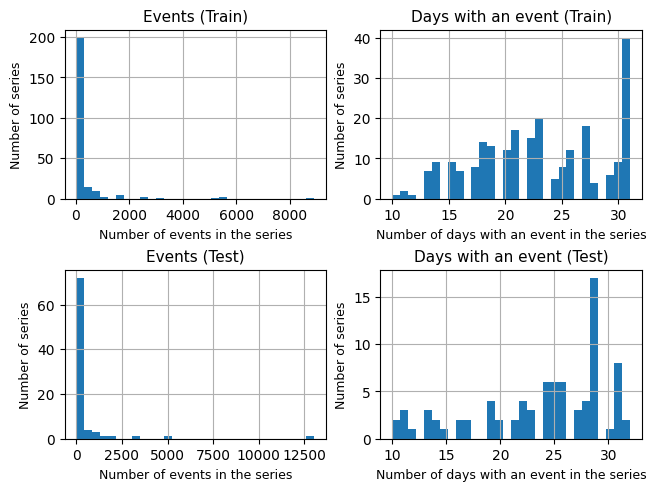

In [9]:
def get_series_stats(series):
    series["Day"] = series["Timestamp"].dt.date
    daily_nb_events = series.drop(columns="Timestamp").groupby(["AlarmId", "Day"]).count()
    series_stats = daily_nb_events["AlarmActivity"].groupby(level="AlarmId").agg(["sum", "count"])
    return series_stats.rename(columns={"sum": "nb_events", "count": "nb_days_with_events"})

train_series_stats = get_series_stats(train_series)
test_series_stats = get_series_stats(test_series)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, layout='constrained')
train_series_stats["nb_events"].hist(ax=ax1, bins=30)
ax1.set_xlabel("Number of events in the series", fontsize=9)
ax1.set_ylabel("Number of series", fontsize=9)
ax1.set_title("Events (Train)", fontsize=11)

train_series_stats["nb_days_with_events"].hist(ax=ax2, bins=30)
ax2.set_xlabel("Number of days with an event in the series", fontsize=9)
ax2.set_ylabel("Number of series", fontsize=9)
ax2.set_title("Days with an event (Train)", fontsize=11)

test_series_stats["nb_events"].hist(ax=ax3, bins=30)
ax3.set_xlabel("Number of events in the series", fontsize=9)
ax3.set_ylabel("Number of series", fontsize=9)
ax3.set_title("Events (Test)", fontsize=11)

test_series_stats["nb_days_with_events"].hist(ax=ax4, bins=30)
ax4.set_xlabel("Number of days with an event in the series", fontsize=9)
ax4.set_ylabel("Number of series", fontsize=9)
ax4.set_title("Days with an event (Test)", fontsize=11)

plt.savefig("events_and_days.png", dpi=300)

In [80]:
# Some more statistics
train_stats2 = pd.DataFrame({
    "date": train_series["Timestamp"].dt.date.agg(["min", "max"]),
    "nb_events": train_series_stats["nb_events"].agg(["min", "mean", "max"]),
    "avg_nb_events_per_day": train_series_stats["nb_events"].agg(["min", "mean", "max"]) / 31,
    "nb_days_with_events": train_series_stats["nb_days_with_events"].agg(["min", "mean", "max"]),
})
test_stats2 = pd.DataFrame({
    "date": test_series["Timestamp"].dt.date.agg(["min", "max"]),
    "nb_events": test_series_stats["nb_events"].agg(["min", "mean", "max"]),
    "avg_nb_events_per_day": test_series_stats["nb_events"].agg(["min", "mean", "max"]) / 32,
    "nb_days_with_events": test_series_stats["nb_days_with_events"].agg(["min", "mean", "max"]),
})
stats2 = pd.concat([train_stats2.unstack().to_frame('Train').T, test_stats2.unstack().to_frame('Test').T], axis=0)
new_cols = [(a, b) for a in stats2.columns.get_level_values(0).unique() for b in ("min", "mean", "max")]
stats2 = stats2.loc[:, new_cols]
stats2 = stats2.drop(("date", "mean"), axis=1)

stats2[("nb_events", "min")] = stats2[("nb_events", "min")].astype(int)
stats2[("nb_events", "max")] = stats2[("nb_events", "max")].astype(int)
stats2[("nb_days_with_events", "min")] = stats2[("nb_days_with_events", "min")].astype(int)
stats2[("nb_days_with_events", "max")] = stats2[("nb_days_with_events", "max")].astype(int)
stats2

date             nb_events                     \
              min         max       min        mean    max   
Train  2024-05-01  2024-05-31        26  309.616034   8911   
Test   2026-01-17  2026-02-17        11  441.404762  13032   

      avg_nb_events_per_day                        nb_days_with_events  \
                        min       mean         max                 min   
Train               0.83871   9.987614  287.451613                  10   
Test                0.34375  13.793899      407.25                  10   

                      
            mean max  
Train  22.970464  31  
Test   23.880952  32